# 🫀 **Heart-AI: Predictive Modeling of Cardiovascular Disease**


---
### 📑 **Índice de Contenidos**
1.  [Descripción y Contexto Clínico](#descripción)
2.  [Análisis Exploratorio (EDA)](#eda)
3.  [Ingeniería de Características y Preprocesamiento](#preprocesamiento)
4.  [Estrategia de Modelado (RF vs GBM vs LR)](#modelado)
5.  [Validación Clínica y Ajuste de Umbral](#evaluación)
6.  [Interpretabilidad y Conclusiones](#conclusiones)
---


## **1. Descripción del Proyecto**

### **Contexto y Problemática**
Las enfermedades cardiovasculares (ECV) representan la principal causa de muerte a nivel mundial. La detección temprana y precisa es fundamental para reducir la mortalidad. Sin embargo, el diagnóstico clínico tradicional puede ser complejo debido a la multitud de factores de riesgo y la variabilidad en la sintomatología de los pacientes.

### **Objetivo**
Este proyecto desarrolla un sistema de inteligencia artificial capaz de predecir la probabilidad de presencia de enfermedad cardiaca en pacientes. Utilizando algoritmos de **Aprendizaje Supervisado (Supervised Learning)**, el modelo analiza patrones complejos en variables clínicas, hemodinámicas y electrocardiográficas para ofrecer una "segunda opinión" probabilística.

### **Metodología**
El flujo de trabajo (*pipeline*) sigue el estándar de la industria para Ciencia de Datos Médica:
1.  **Análisis Exploratorio de Datos (EDA):** Evaluación estadística de variables y correlaciones fisiológicas.
2.  **Preprocesamiento Clínico:** Imputación de datos faltantes basada en lógica médica (e.g., corrección de valores nulos en presión arterial) y estandarización de variables.
3.  **Modelado Predictivo:** Entrenamiento y validación de arquitecturas de ensamble (*Random Forest, Gradient Boosting*) y modelos lineales (*Regresión Logística*).
4.  **Evaluación de Riesgo:** Optimización del modelo priorizando la **Sensibilidad (Recall)** para minimizar los falsos negativos en el diagnóstico.

### **Impacto y Utilidad**
Esta herramienta no pretende sustituir al juicio médico, sino actuar como un **Sistema de Soporte a la Decisión Clínica (CDSS)**. Su implementación permitiría:
* Agilizar el triaje en servicios de urgencias.
* Identificar pacientes de alto riesgo que requieren pruebas invasivas (angiografías) prioritarias.
* Detectar patrones sutiles en pruebas no invasivas (ECG, pruebas de esfuerzo) que podrían pasar desapercibidos.

---

## **2. Fuente de Datos y Adquisición**

El estudio utiliza el **"Heart Disease Dataset"**, un conjunto de datos consolidado disponible en Kaggle. Esta base de datos es una de las más completas en la literatura, combinando 5 cohortes históricas famosas:
* Cleveland Clinic Foundation (USA)
* Hungarian Institute of Cardiology (Hungría)
* V.A. Medical Center, Long Beach (USA)
* University Hospital, Zurich (Suiza)
* Stalog (Heart) Data Set

**Referencia del Dataset:** [Heart Disease Dataset (Mexwell)](https://www.kaggle.com/datasets/mexwell/heart-disease-dataset)

### **Conexión a la API**
Para garantizar la reproducibilidad y obtener la versión más reciente de los datos, utilizamos la librería `kagglehub`:

```python
import kagglehub
import pandas as pd

# Descarga de la última versión del dataset desde Kaggle
path = kagglehub.dataset_download("mexwell/heart-disease-dataset")

print("Ruta de descarga de los archivos:", path)

# Nota: El path devuelto se utilizará en la siguiente celda para cargar el CSV
# df = pd.read_csv(f"{path}/heart.csv")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display # Para mostrar tablas con formato html

# --- 1. Configuración del Entorno y Estilos ---
warnings.filterwarnings('ignore')

# Configuración visual para gráficos de alta calidad (Paper quality)
sns.set_theme(style="whitegrid", context="notebook", palette="viridis")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Configuración de Pandas para visualización numérica
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)

# --- 2. Carga de Datos ---
# Definimos la ruta en una variable para facilitar cambios futuros
DATASET_PATH = 'heart_dataset.csv'

try:
    df = pd.read_csv(DATASET_PATH)
    print(f"✅ Dataset cargado exitosamente: {df.shape[0]} pacientes, {df.shape[1]} variables.")
except FileNotFoundError:
    print(f"❌ ERROR CRÍTICO: No se encontró el archivo '{DATASET_PATH}'.")
    print("Asegúrate de haber ejecutado la descarga con kagglehub o subido el archivo.")

# --- 3. Auditoría Inicial de Datos ---

print("\n🔍 --- Vista Previa (Primeros 5 registros) ---")
display(df.head())

print("\n📊 --- Estadísticas Descriptivas (Transpuesta para lectura) ---")
# .T invierte filas y columnas, facilitando la lectura cuando hay muchas variables
display(df.describe().T)

print("\n🛠 --- Estructura y Tipos de Datos ---")
df.info()

print("\n⚖️ --- Balance de Clases (Variable Objetivo) ---")
# Mostramos el balance con formato de porcentaje
class_balance = df['target'].value_counts(normalize=True).to_frame(name='Proporción')
display(class_balance.style.format("{:.2%}"))

✅ Dataset cargado exitosamente: 1190 pacientes, 12 variables.

🔍 --- Vista Previa (Primeros 5 registros) ---


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.00,1,0
1,49,0,3,160,180,0,0,156,0,1.00,2,1
2,37,1,2,130,283,0,1,98,0,0.00,1,0
3,48,0,4,138,214,0,0,108,1,1.50,2,1
4,54,1,3,150,195,0,0,122,0,0.00,1,0



📊 --- Estadísticas Descriptivas (Transpuesta para lectura) ---


,count,mean,std,min,25%,50%,75%,max
age,1190.00,53.72,9.36,28.00,47.00,54.00,60.00,77.00
sex,1190.00,0.76,0.42,0.00,1.00,1.00,1.00,1.00
chest pain type,1190.00,3.23,0.94,1.00,3.00,4.00,4.00,4.00
resting bp s,1190.00,132.15,18.37,0.00,120.00,130.00,140.00,200.00
cholesterol,1190.00,210.36,101.42,0.00,188.00,229.00,269.75,603.00
fasting blood sugar,1190.00,0.21,0.41,0.00,0.00,0.00,0.00,1.00
resting ecg,1190.00,0.70,0.87,0.00,0.00,0.00,2.00,2.00
max heart rate,1190.00,139.73,25.52,60.00,121.00,140.50,160.00,202.00
exercise angina,1190.00,0.39,0.49,0.00,0.00,0.00,1.00,1.00
oldpeak,1190.00,0.92,1.09,-2.60,0.00,0.60,1.60,6.20



🛠 --- Estructura y Tipos de Datos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB

⚖️ --- Balance de Clases (Variable Objetivo) ---


,Proporción
target,
1,52.86%
0,47.14%


## **3. Análisis Exploratorio de Datos (EDA): Evaluación de Correlaciones y Factores Demográficos**

Antes de proceder con el modelado predictivo, es fundamental validar la coherencia biológica de los datos y entender las relaciones subyacentes entre las variables clínicas. Esta fase se centra en dos objetivos diagnósticos:

### **3.1. Matriz de Correlación de Pearson**
El análisis de correlaciones permite identificar **biomarcadores clave** que tienen una fuerte asociación lineal con la enfermedad cardiaca. Buscamos específicamente variables con alta correlación positiva o negativa con el *target*, lo que sugiere un alto poder predictivo (e.g., alteraciones en el segmento ST). Simultáneamente, este análisis nos ayuda a vigilar la **multicolinealidad** (redundancia entre variables independientes), la cual podría introducir sesgos en modelos lineales como la Regresión Logística.

### **3.2. Impacto del Factor Edad**
La edad es, por definición, un factor de riesgo no modificable en la patología cardiovascular. Mediante el análisis de la distribución de densidad, evaluamos si nuestra cohorte refleja el comportamiento epidemiológico esperado: una mayor prevalencia de enfermedad (desplazamiento de la curva de densidad) en los rangos de edad avanzada, contrastado con la población sana.

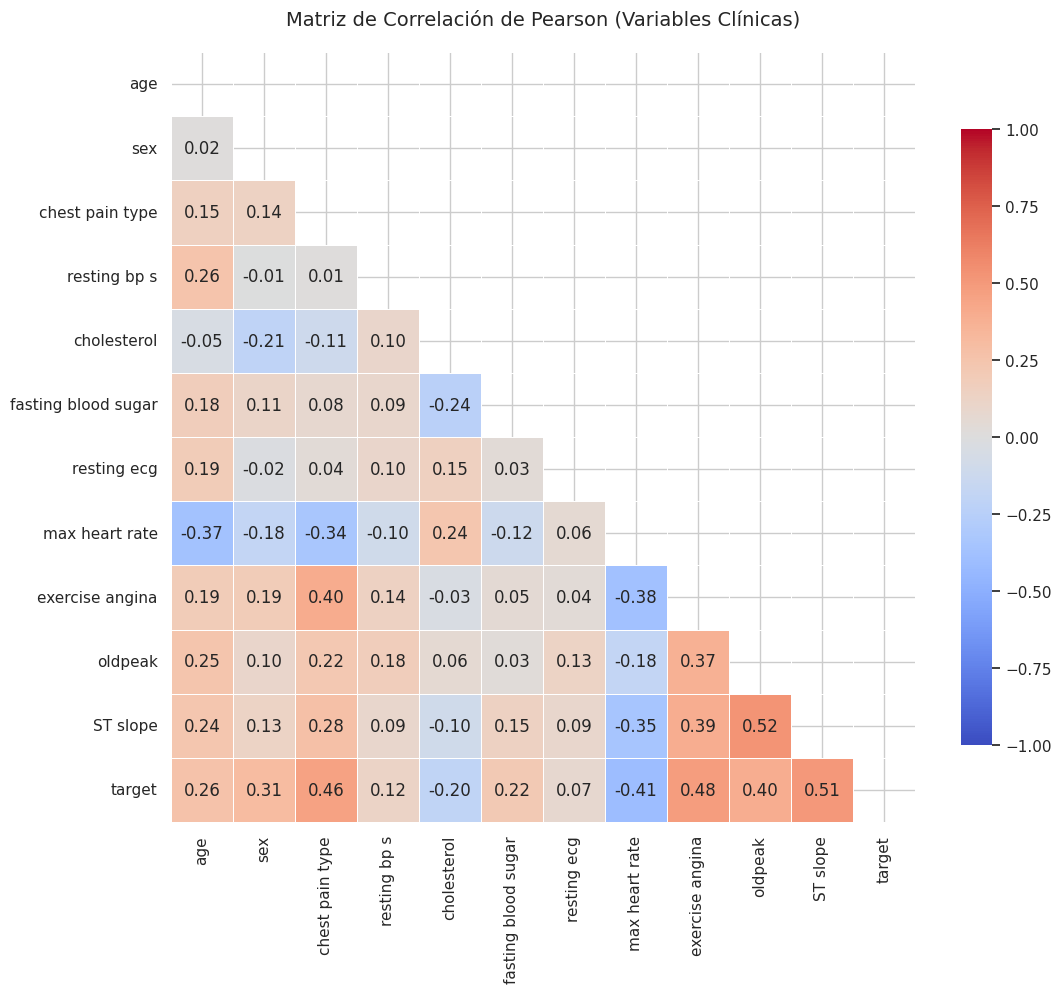

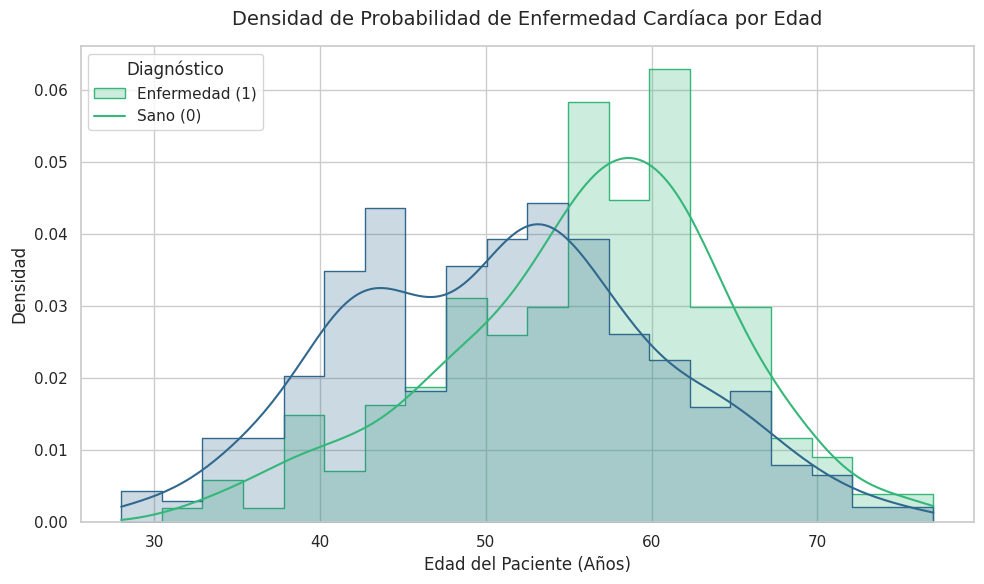

In [2]:
# --- 3.1. Mapa de Calor de Correlaciones (Triangular) ---
plt.figure(figsize=(12, 10))

# Calcular matriz de correlación (asegurando solo numéricas)
corr_matrix = df.corr(numeric_only=True)

# Crear una máscara para ocultar el triángulo superior (redundante: correlación AB es lo mismo que correlación BA)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Generar el heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,              # Aplica la máscara
    annot=True,             # Muestra los valores
    fmt=".2f",              # 2 decimales
    cmap='coolwarm',        # Paleta divergente (Rojo=Positivo, Azul=Negativo)
    vmax=1, vmin=-1,        # Límites normalizados
    linewidths=0.5,         # Separación entre celdas
    cbar_kws={"shrink": .8} # Barra de color ajustada
)

plt.title('Matriz de Correlación de Pearson (Variables Clínicas)', fontsize=14, pad=20)
plt.show()

print()
print()

# --- 3.2. Distribución Demográfica del Riesgo ---
plt.figure(figsize=(10, 6))

# Histograma con estimación de densidad (KDE)
ax = sns.histplot(
    data=df,
    x='age',
    hue='target',
    kde=True,
    palette='viridis',
    element="step",       # Estilo visual más limpio
    stat="density",       # Normalizar para comparar distribuciones
    common_norm=False     # Normalizar cada grupo independientemente
)

# Personalización profesional de etiquetas
plt.title('Densidad de Probabilidad de Enfermedad Cardíaca por Edad', fontsize=14, pad=15)
plt.xlabel('Edad del Paciente (Años)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

# Ajuste manual de la leyenda para que sea legible (No 0/1)
plt.legend(title='Diagnóstico', labels=['Enfermedad (1)', 'Sano (0)'], loc='upper left')

plt.tight_layout()
plt.show()

## **4. Saneamiento de Datos y Validación de Consistencia Fisiológica**

### **4.1. Estandarización del Esquema**
Para garantizar la interoperabilidad sintáctica con el pipeline de entrenamiento, se normaliza la nomenclatura de las variables, eliminando espacios y caracteres especiales. Esto asegura la compatibilidad con los atributos internos de los estimadores de *Scikit-Learn*.

### **4.2. Tratamiento de Valores Biológicamente Inverosímiles**
Durante la auditoría de calidad de los datos, se detectaron registros con valor `0` en variables hemodinámicas críticas:
* **Presión Arterial en Reposo (`resting_bp_s`)**
* **Colesterol Sérico (`cholesterol`)**

Desde una perspectiva fisiológica, una presión arterial o un nivel de colesterol de `0` son incompatibles con la vida. Por tanto, estos registros se clasifican como **artefactos de medición** o datos faltantes no codificados.

**Estrategia:** Se procede a su re-codificación explícita como `NaN` (Not a Number). Esta acción es crítica para evitar que el modelo aprenda relaciones espurias (e.g., que tener colesterol 0 protege del infarto) y permite la activación de estrategias de imputación estadística en la fase de preprocesamiento.

In [3]:
# --- 1. Normalización de Nomenclatura (Snake Case) ---
df.columns = df.columns.str.strip().str.replace(' ', '_')

# --- 2. Corrección de Anomalías Fisiológicas ---
# Lista de variables donde el valor 0 se considera error de captura
physiological_cols = ['resting_bp_s', 'cholesterol']

# Reemplazo vectorial de 0 por NaN
for col in physiological_cols:
    df[col] = df[col].replace(0, np.nan)

# --- 3. Reporte de Integridad Post-Corrección ---
# Calculamos cantidad y porcentaje de datos perdidos recuperados
missing_report = df[physiological_cols].isnull().sum().to_frame(name='Registros Recuperados (NaN)')
missing_report['% del Dataset'] = (missing_report['Registros Recuperados (NaN)'] / len(df)) * 100

print(f"⚠️ Reporte de Calidad de Datos: Valores fisiológicamente imposibles corregidos")
display(missing_report.style.format({'% del Dataset': '{:.2f}%'}).background_gradient(cmap='Reds'))


⚠️ Reporte de Calidad de Datos: Valores fisiológicamente imposibles corregidos


,Registros Recuperados (NaN),% del Dataset
resting_bp_s,1,0.08%
cholesterol,172,14.45%


## **5. Estratificación de Variables y Definición del Espacio de Características**

Para la correcta ingestión de los datos en los algoritmos de aprendizaje supervisado, se procede a la segregación de la variable dependiente (Target) y la clasificación taxonómica de los predictores. Esta etapa es prerrequisito para la construcción de pipelines de preprocesamiento diferenciados.

### **5.1. Segregación del Vector Objetivo**
Se aísla la variable `target` ($y$) de la matriz de características ($X$).
* **$X$ (Matriz de Diseño):** Contiene la información fenotípica y clínica de los pacientes.
* **$y$ (Vector Objetivo):** Variable binaria que codifica el estado de salud (0: Sano, 1: Patología Cardiaca).

### **5.2. Taxonomía de Variables (Tipado Semántico)**
Los algoritmos matemáticos requieren tratamientos distintos según la naturaleza de la variable:

* **Variables Cualitativas (Categóricas):** Incluyen datos nominales (e.g., `sex`, `chest_pain_type`) y binarios. Estas variables no poseen una magnitud matemática intrínseca y requerirán técnicas de codificación (como *One-Hot Encoding*) para proyectarlas en un espacio vectorial sin introducir una jerarquía ordinal artificial.
* **Variables Cuantitativas (Numéricas):** Variables continuas o discretas con magnitud física real (e.g., `age`, `cholesterol`). Estas requerirán estandarización estadística (Scaling) para homogeneizar sus rangos y facilitar la convergencia de modelos sensibles a la distancia euclidiana (como SVM o Regresión Logística).

In [4]:
# --- 1. Definición de Matriz de Características (X) y Vector Objetivo (y) ---
X = df.drop('target', axis=1)
y = df['target']

# --- 2. Clasificación Semántica de Variables ---

# Variables Categóricas: Nominales, Ordinales y Binarias
# Se definen explícitamente para asegurar su correcto tratamiento en el encoding
categorical_cols = [
    'sex',
    'chest_pain_type',
    'fasting_blood_sugar',
    'resting_ecg',
    'exercise_angina',
    'ST_slope'
]

# Variables Numéricas: Se obtienen por exclusión (Set difference)
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# --- 3. Auditoría de Dimensiones ---
print(f"✅ Dimensiones de X: {X.shape}")
print(f"✅ Dimensiones de y: {y.shape}")

print("\n📋 --- Taxonomía de Variables Definida ---")
print(f"🔹 Variables Categóricas ({len(categorical_cols)}): {categorical_cols}")
print(f"🔸 Variables Numéricas   ({len(numerical_cols)}): {numerical_cols}")

# Validación de integridad (Check de seguridad)
assert len(categorical_cols) + len(numerical_cols) == X.shape[1], "❌ Error: Faltan columnas por clasificar."


✅ Dimensiones de X: (1190, 11)
✅ Dimensiones de y: (1190,)

📋 --- Taxonomía de Variables Definida ---
🔹 Variables Categóricas (6): ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'resting_ecg', 'exercise_angina', 'ST_slope']
🔸 Variables Numéricas   (5): ['age', 'resting_bp_s', 'cholesterol', 'max_heart_rate', 'oldpeak']


## **6. Evaluación de Prevalencia y Balance de Clases**

La distribución de la variable objetivo (`target`) es un determinante crítico en la estrategia de modelado. Un desequilibrio severo (e.g., 90% sanos vs. 10% enfermos) induciría un **sesgo de aprendizaje** hacia la clase mayoritaria, invalidando la "Exactitud" (*Accuracy*) como métrica de desempeño.

En esta fase, cuantificamos la **prevalencia** de la patología en la cohorte de estudio para determinar si es necesario aplicar técnicas de re-muestreo (como SMOTE o *Undersampling*) o si el dataset posee un balance natural suficiente para el entrenamiento directo.

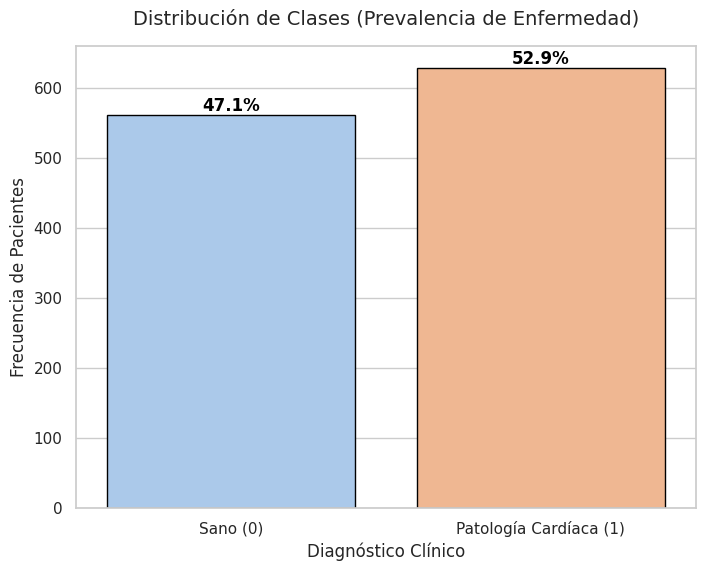

📊 Reporte de Balance:
   - Pacientes Sanos (0):    561 (47.1%)
   - Pacientes Enfermos (1): 629 (52.9%)
   - Ratio Enfermo/Sano:     1.12
✅ Conclusión: El dataset está BALANCEADO. No se requiere re-muestreo artificial.


In [5]:
# --- 6. Visualización de la Prevalencia ---
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=df,
    x='target',
    palette='pastel',
    edgecolor='black'
)

# Personalización de Ejes
plt.title('Distribución de Clases (Prevalencia de Enfermedad)', fontsize=14, pad=15)
plt.xlabel('Diagnóstico Clínico', fontsize=12)
plt.ylabel('Frecuencia de Pacientes', fontsize=12)
ax.set_xticklabels(['Sano (0)', 'Patología Cardíaca (1)'])

# --- Añadir anotaciones de porcentaje sobre las barras ---
total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

plt.show()

# --- Diagnóstico Numérico del Balance ---
count_sanos = df['target'].value_counts()[0]
count_enfermos = df['target'].value_counts()[1]
ratio = count_enfermos / count_sanos

print(f"📊 Reporte de Balance:")
print(f"   - Pacientes Sanos (0):    {count_sanos} ({count_sanos/total:.1%})")
print(f"   - Pacientes Enfermos (1): {count_enfermos} ({count_enfermos/total:.1%})")
print(f"   - Ratio Enfermo/Sano:     {ratio:.2f}")

# Regla de decisión para imprimir conclusión
if 0.8 < ratio < 1.2:
    print("✅ Conclusión: El dataset está BALANCEADO. No se requiere re-muestreo artificial.")
else:
    print("⚠️ Conclusión: Existe un DESBALANCE significativo. Se recomienda ajustar métricas (F1-Score).")

## **7. Análisis de Separabilidad: Distribuciones Condicionales de Biomarcadores**

Para evaluar el poder discriminante de las variables continuas, analizamos sus funciones de densidad de probabilidad condicionadas a la clase objetivo ($P(X | Y)$). Este análisis visual nos permite identificar **biomarcadores fuertes**, caracterizados por una baja superposición (solapamiento) entre las distribuciones de pacientes sanos y enfermos.

Se han seleccionado cuatro indicadores fisiopatológicos clave para este diagnóstico:

1.  **Reserva Cronotrópica (`max_heart_rate`):** La incapacidad de alcanzar frecuencias cardiacas altas bajo estrés suele asociarse con insuficiencia cardiaca. Esperamos ver un desplazamiento a la izquierda en pacientes enfermos.
2.  **Isquemia Inducida (`oldpeak`):** La depresión del segmento ST es un signo electrocardiográfico clásico de isquemia. Una distribución de "cola larga" hacia la derecha indicaría alto riesgo.
3.  **Perfil Metabólico (`cholesterol`):** Aunque es un factor de riesgo clásico, analizaremos si por sí solo ofrece una separación clara en esta cohorte específica.
4.  **Hemodinámica en Reposo (`resting_bp_s`):** La hipertensión sistólica como factor agravante.

**Interpretación:** Una divergencia clara entre las curvas (Sano vs. Patología) sugiere que la variable será un predictor de alto rendimiento en modelos como *Random Forest*.

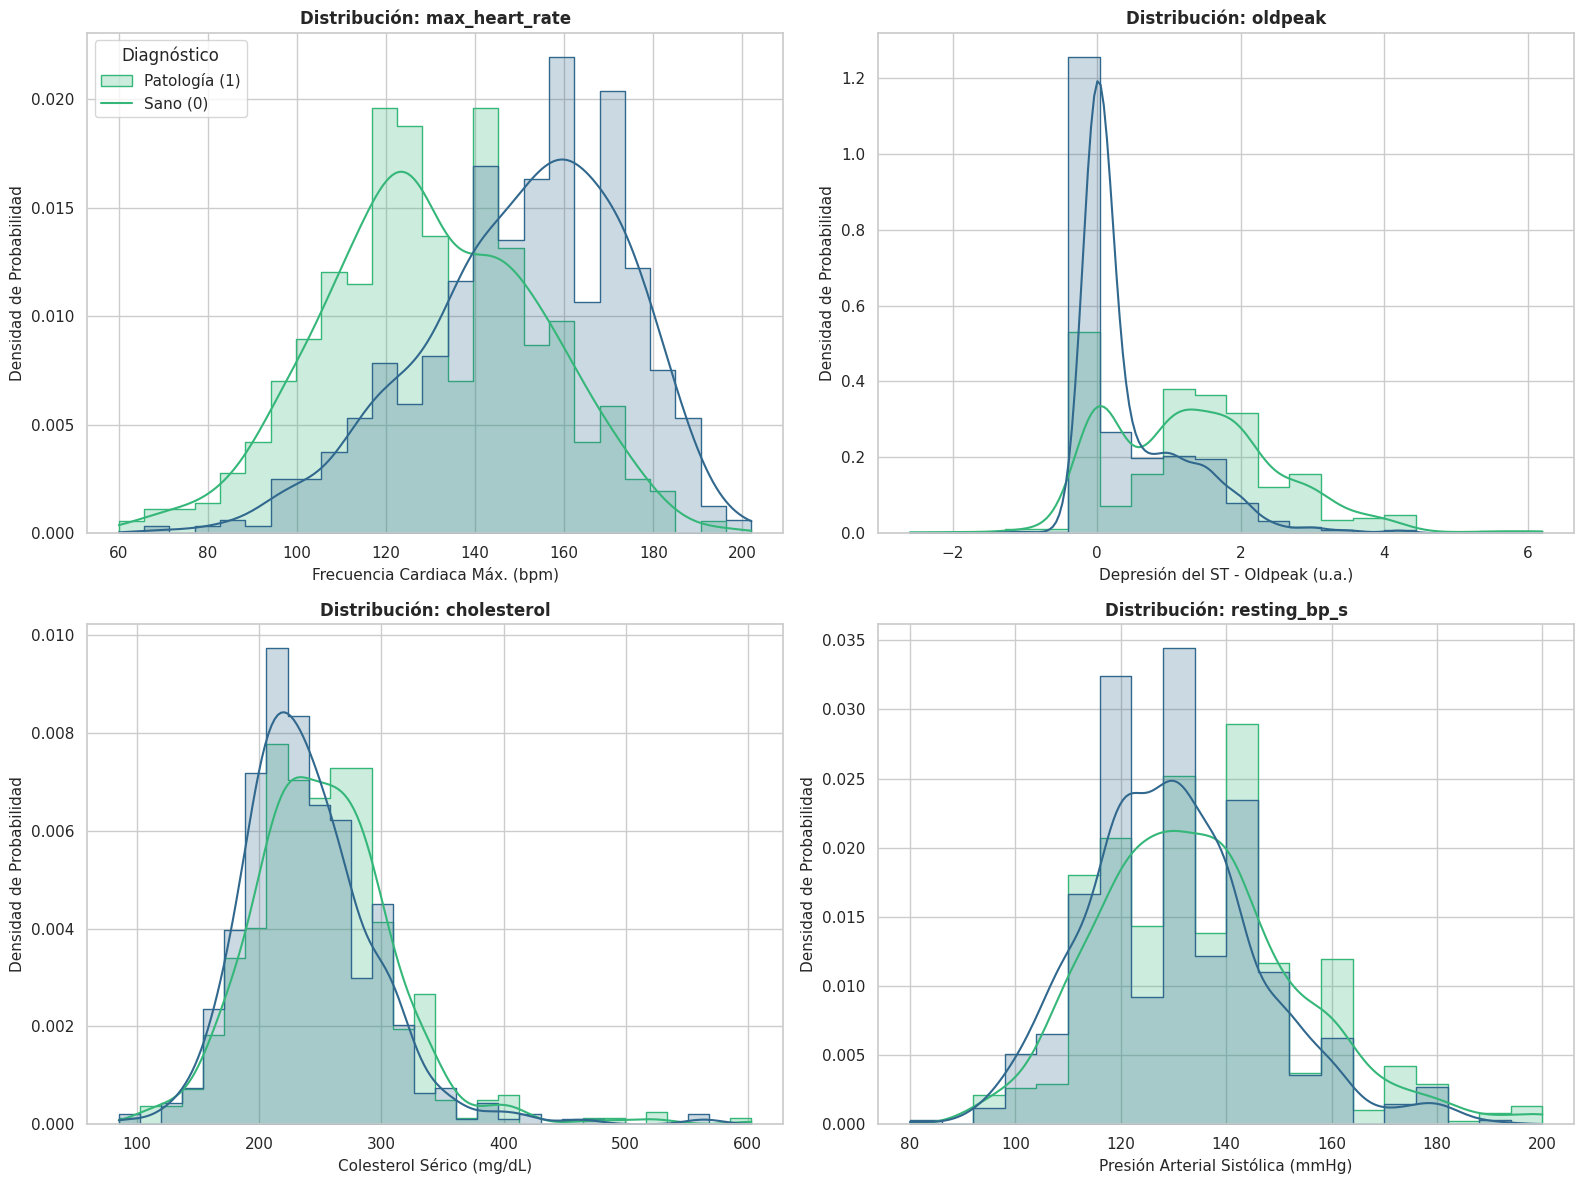

In [6]:
# --- 7. Panel de Distribuciones Condicionales ---

# Definición de metadatos para etiquetas profesionales (Unidades médicas)
features_meta = {
    'max_heart_rate': {'label': 'Frecuencia Cardiaca Máx. (bpm)', 'bins': 25},
    'oldpeak':        {'label': 'Depresión del ST - Oldpeak (u.a.)', 'bins': 20},
    'cholesterol':    {'label': 'Colesterol Sérico (mg/dL)', 'bins': 30},
    'resting_bp_s':   {'label': 'Presión Arterial Sistólica (mmHg)', 'bins': 20}
}

# Configuración del Grid de Gráficos (2 filas x 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() # Aplanar para iterar fácilmente

for i, (col, meta) in enumerate(features_meta.items()):
    ax = axes[i]

    # Histograma con estimación de densidad (KDE)
    sns.histplot(
        data=df,
        x=col,
        hue='target',
        kde=True,
        stat='density',     # Normalizar áreas a 1 para comparar formas
        common_norm=False,  # Densidad independiente por grupo
        palette='viridis',
        element="step",
        ax=ax,              # Dibujar en el sub-eje específico
        bins=meta['bins']
    )

    # Personalización clínica
    ax.set_title(f'Distribución: {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(meta['label'], fontsize=11)
    ax.set_ylabel('Densidad de Probabilidad', fontsize=11)

    # Leyenda limpia (solo en el primer gráfico para no saturar)
    if i == 0:
        ax.legend(title='Diagnóstico', labels=['Patología (1)', 'Sano (0)'])
    else:
        ax.get_legend().remove() # Ocultar leyenda redundante

plt.tight_layout() # Ajuste automático de espacios
plt.show()

## **8. Evaluación de Isquemia Miocárdica: Análisis de `oldpeak`**

La variable `oldpeak` cuantifica la **depresión del segmento ST** (en mm) inducida por el ejercicio en relación con el reposo. Desde una perspectiva clínica, este fenómeno electrocardiográfico es un marcador "gold standard" para el diagnóstico de **isquemia subendocárdica** (falta de riego sanguíneo al corazón bajo estrés).

### **Hipótesis de Separabilidad**
En este análisis de dispersión, evaluamos la capacidad de `oldpeak` para discriminar entre las clases objetivo.
* **Grupo Patológico (1):** Esperamos observar una distribución desplazada hacia valores superiores (> 1-2 mm), indicativa de respuesta isquémica anormal.
* **Grupo Control (0):** Debería concentrarse en valores cercanos a 0 (ausencia de depresión del ST).

El diagrama de cajas (*Boxplot*) nos permite no solo comparar las tendencias centrales (medianas), sino también identificar la **varianza clínica** dentro de los grupos y detectar **valores atípicos** (*outliers*) que podrían corresponder a casos de severidad extrema o errores de captura.

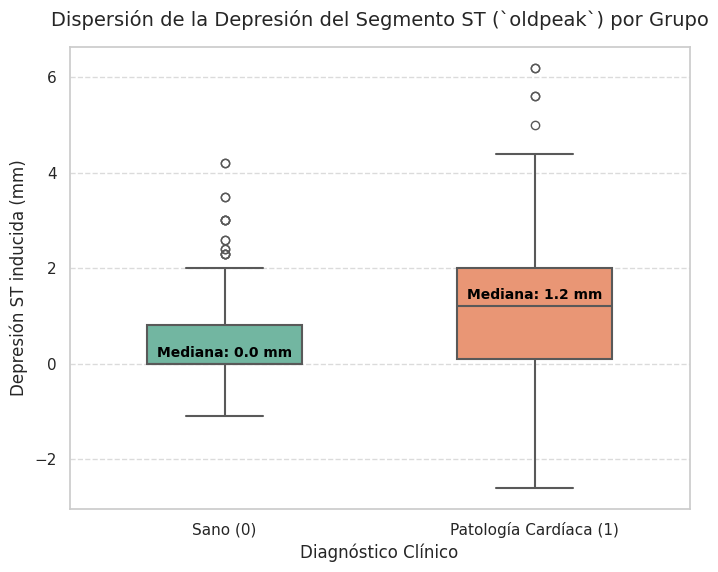

In [7]:
# --- 8. Análisis de Dispersión: Oldpeak vs Target ---
plt.figure(figsize=(8, 6))

# Generación del Boxplot con estética mejorada
ax = sns.boxplot(
    data=df,
    x='target',
    y='oldpeak',
    palette='Set2',       # Paleta profesional (distintiva pero suave)
    width=0.5,            # Cajas más estilizadas (menos "bloque")
    linewidth=1.5
)

# --- Personalización Clínica (Etiquetas Profesionales) ---
plt.title('Dispersión de la Depresión del Segmento ST (`oldpeak`) por Grupo', fontsize=14, pad=15)
plt.xlabel('Diagnóstico Clínico', fontsize=12)
plt.ylabel('Depresión ST inducida (mm)', fontsize=12)

# Mapeo de etiquetas del eje X (Semántica en lugar de 0/1)
ax.set_xticklabels(['Sano (0)', 'Patología Cardíaca (1)'])

# --- Valor Añadido: Anotación de Medianas ---
# Calculamos la mediana para cada grupo para mostrarla en el gráfico
medians = df.groupby(['target'])['oldpeak'].median().values

# Escribimos el valor exacto sobre cada caja para facilitar la lectura
# (Así el lector no tiene que adivinar si es 0.5 o 0.6)
for i, median in enumerate(medians):
    ax.text(
        i, median + 0.15,      # Posición (x, y)
        f'Mediana: {median} mm',
        horizontalalignment='center',
        size='small',
        color='black',
        weight='semibold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.7) # Rejilla horizontal para referencia
plt.show()

## **9. Arquitectura del Pipeline de Preprocesamiento**

La calidad de un modelo predictivo depende intrínsecamente de la transformación matemática de los datos crudos. En esta fase, diseñamos un **Pipeline de Ingeniería de Datos** automatizado que garantiza la reproducibilidad y evita la fuga de información (*data leakage*) entre los conjuntos de entrenamiento y validación.

### **9.1. Estrategia de Imputación y Escalado**
* **Variables Numéricas:** Se implementa una imputación estadística basada en la **Mediana** por ser un estimador robusto frente a valores atípicos (*outliers*) en variables fisiológicas no gaussianas (como el colesterol). Posteriormente, se aplica estandarización Z-Score (`StandardScaler`) para centrar los datos ($\mu=0, \sigma=1$), requisito fundamental para la convergencia óptima de algoritmos basados en gradiente y distancia (SVM, Regresión Logística).
* **Variables Categóricas:** Se aplica codificación ortogonal (*One-Hot Encoding*) para proyectar las categorías nominales en un espacio vectorial binario, evitando introducir relaciones ordinales inexistentes.

### **9.2. Particionamiento Estratificado**
Se divide el corpus de datos en subconjuntos de Entrenamiento (80%) y Prueba (20%). Para preservar la representatividad epidemiológica, utilizamos un muestreo **estratificado** (`stratify=y`). Esto asegura que la prevalencia de la enfermedad se mantenga idéntica en ambos subconjuntos, validando que el modelo sea evaluado en un escenario fiel a la realidad del dataset original.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# --- 9. Construcción del Pipeline de Transformación ---

# Definición de transformadores por tipo de variable
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Robustez ante outliers
    ('scaler', StandardScaler())                   # Normalización Z-Score
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Manejo de categorías nuevas
])

# Integración en el Preprocesador Maestro
# Nota: Usamos las listas 'numerical_cols' y 'categorical_cols' definidas en la Sección 5
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    verbose_feature_names_out=False # Mantiene nombres de columnas limpios
)

# --- División Estratificada (Hold-Out Set) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% para evaluación final
    random_state=42,    # Reproducibilidad
    stratify=y          # Mantiene la prevalencia de enfermedad constante
)

# --- Auditoría de Dimensiones del Split ---
print("✅ Particionamiento completado exitosamente:")
print(f"   - Set de Entrenamiento: {X_train.shape[0]} pacientes ({X_train.shape[0]/len(X):.1%})")
print(f"   - Set de Prueba (Test): {X_test.shape[0]} pacientes ({X_test.shape[0]/len(X):.1%})")

# Validación de integridad
assert X_train.shape[0] + X_test.shape[0] == len(X)
assert X_train.shape[0] == y_train.shape[0]

✅ Particionamiento completado exitosamente:
   - Set de Entrenamiento: 952 pacientes (80.0%)
   - Set de Prueba (Test): 238 pacientes (20.0%)


## **10. Estrategia de Modelado y Entrenamiento Comparativo**

Para abordar el problema de clasificación binaria, se ha diseñado un experimento comparativo utilizando tres arquitecturas algorítmicas que cubren el espectro del compromiso sesgo-varianza (*Bias-Variance Tradeoff*):

### **10.1. Selección de Algoritmos**
1.  **Regresión Logística (Baseline Lineal):**
    * **Justificación:** Modelo paramétrico lineal (GLM). Su simplicidad y alta interpretabilidad (a través de los *Odds Ratios*) lo convierten en el estándar médico de referencia. Sirve para establecer una línea base de rendimiento.
2.  **Random Forest (Bagging - Reducción de Varianza):**
    * **Justificación:** Método de ensamble que promedia múltiples árboles de decisión descorrelacionados. Es intrínsecamente robusto frente al sobreajuste (*overfitting*) en datasets de alta dimensionalidad y captura relaciones no lineales sin requerir escalado complejo (aunque nuestro pipeline lo incluye por consistencia).
3.  **Gradient Boosting (Boosting - Reducción de Sesgo):**
    * **Justificación:** Construye un modelo aditivo fuerte optimizando una función de pérdida diferenciable. Suele ofrecer la máxima capacidad predictiva en datos tabulares al corregir secuencialmente los errores de los estimadores previos.

### **10.2. Encapsulamiento en Pipelines**
Para garantizar la integridad metodológica, cada modelo se integra en un objeto `Pipeline` de Scikit-Learn. Esto asegura que los pasos de preprocesamiento (imputación y escalado) se ajusten *exclusivamente* con los datos de entrenamiento en cada iteración, previniendo la **fuga de datos** (*Data Leakage*) del conjunto de prueba.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import time

# --- Definición del Diccionario de Modelos ---
# Se fijan semillas (random_state) para garantizar reproducibilidad exacta
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42)
}

# Diccionario para almacenar los pipelines entrenados
trained_models = {}

print("🚀 Iniciando protocolo de entrenamiento experimental...\n")

for name, model in models.items():
    start_time = time.time() # Cronómetro

    # Construcción del Pipeline: Preprocesador + Estimador
    # El preprocessor es el objeto ColumnTransformer definido en la sección anterior
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Ajuste del modelo
    clf.fit(X_train, y_train)

    # Almacenamiento y reporte
    elapsed_time = time.time() - start_time
    trained_models[name] = clf

    print(f"✅ {name:<20} | Entrenado en {elapsed_time:.3f} s")

print("\n🏁 Todos los modelos han sido compilados y almacenados en memoria.")

🚀 Iniciando protocolo de entrenamiento experimental...

✅ Logistic Regression  | Entrenado en 0.082 s
✅ Random Forest        | Entrenado en 0.761 s
✅ Gradient Boosting    | Entrenado en 0.582 s

🏁 Todos los modelos han sido compilados y almacenados en memoria.


## **11. Protocolo de Evaluación: Métricas de Desempeño Clínico**

Para validar la eficacia de los algoritmos como herramientas de soporte al diagnóstico, se evalúa su capacidad de generalización sobre el conjunto de prueba ($X_{test}$). La evaluación se rige por una jerarquía de métricas adaptada al riesgo sanitario:

### **11.1. Criterio de Decisión: Sensibilidad (Recall)**
En el cribado de patologías graves, el coste de un **Falso Negativo** (no detectar a un paciente enfermo) es inaceptablemente alto, pudiendo derivar en falta de tratamiento y mortalidad. Por tanto, priorizamos la **Sensibilidad** (*Recall*) sobre la Precisión pura.
$$Recall = \frac{TP}{TP + FN}$$
Buscamos maximizar esta métrica para minimizar los pacientes enfermos erróneamente clasificados como sanos (Error Tipo II).

### **11.2. Análisis de Matriz de Confusión**
Más allá de las métricas globales, analizamos la distribución de errores:
* **Falsos Negativos (Cuadrante Inferior Izquierdo):** El error crítico a evitar.
* **Falsos Positivos (Cuadrante Superior Derecho):** "Falsas alarmas". Aunque generan ansiedad y costes por pruebas confirmatorias, son clínicamente más tolerables que dejar pasar una cardiopatía.

### **11.3. Métricas de Soporte**
* **F1-Score:** Media armónica que penaliza los desbalances extremos entre precisión y sensibilidad.
* **Accuracy:** Se reporta como referencia global, aunque su relevancia es secundaria frente a la sensibilidad en este contexto.

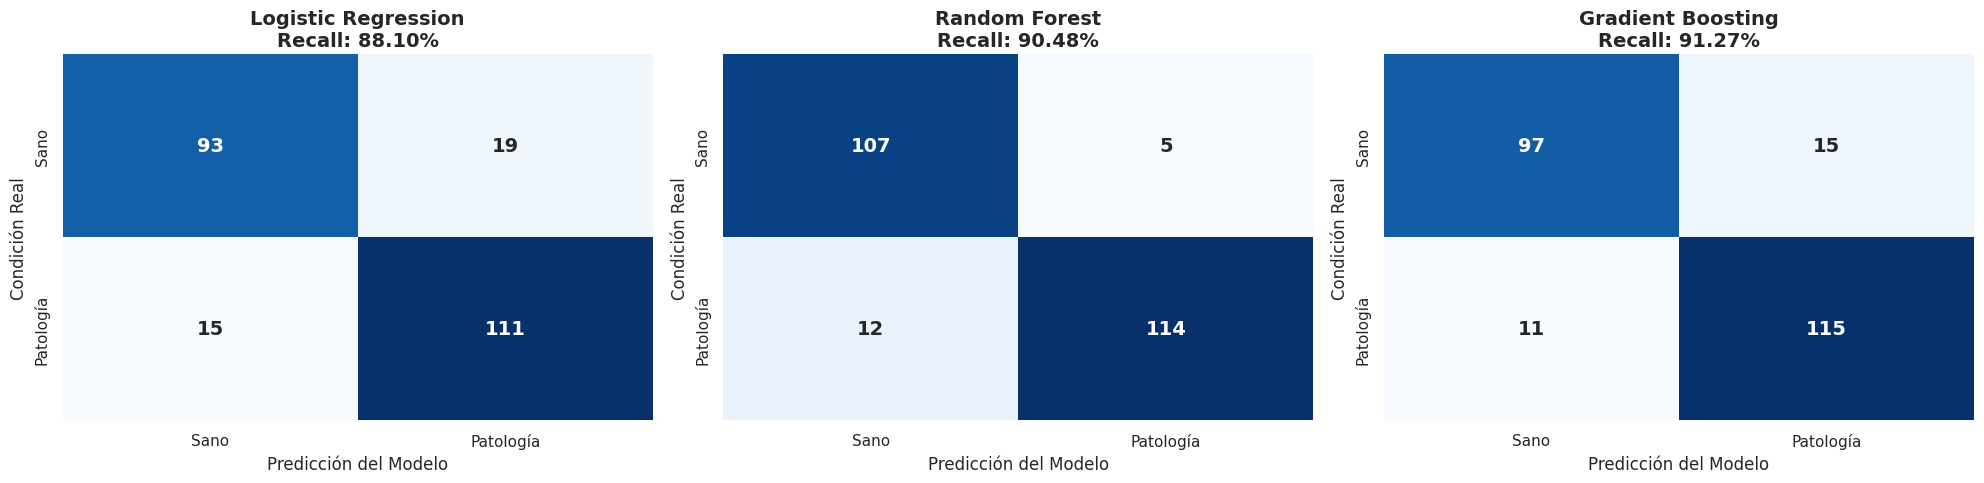


📊 --- Tabla Comparativa de Rendimiento ---


,Accuracy,Sensibilidad (Recall),F1-Score
Modelo,,,
Logistic Regression,85.71%,88.10%,86.72%
Random Forest,92.86%,90.48%,93.06%
Gradient Boosting,89.08%,91.27%,89.84%


In [10]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix

# --- 11. Ejecución del Protocolo de Evaluación ---

# Inicialización de estructuras para reporte
metrics_summary = []
fig, axes = plt.subplots(1, 3, figsize=(20, 5)) # Grid de 1 fila x 3 columnas

for i, (name, model) in enumerate(trained_models.items()):
    # Inferencia
    y_pred = model.predict(X_test)

    # Cálculo de métricas
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Guardar para tabla comparativa
    metrics_summary.append({
        'Modelo': name,
        'Accuracy': acc,
        'Sensibilidad (Recall)': rec,
        'F1-Score': f1
    })

    # --- Visualización de Matriz de Confusión ---
    cm = confusion_matrix(y_test, y_pred)

    # Heatmap en el subplot correspondiente
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=axes[i], # Dibujar en el eje i
        annot_kws={"size": 14, "weight": "bold"}
    )

    # Personalización del gráfico
    axes[i].set_title(f'{name}\nRecall: {rec:.2%}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Condición Real', fontsize=12)
    axes[i].set_xlabel('Predicción del Modelo', fontsize=12)
    axes[i].set_xticklabels(['Sano', 'Patología'])
    axes[i].set_yticklabels(['Sano', 'Patología'])

plt.tight_layout()
plt.show()

# --- Reporte Tabular Final ---
metrics_df = pd.DataFrame(metrics_summary).set_index('Modelo')
print("\n📊 --- Tabla Comparativa de Rendimiento ---")
# Resaltamos el mejor valor de cada columna para facilitar la decisión
display(metrics_df.style.highlight_max(color='lightgreen', axis=0).format("{:.2%}"))

## **12. Análisis de Estabilidad mediante Validación Cruzada Estratificada**

Una evaluación basada en una única partición (*Hold-Out*) puede estar sesgada por la aleatoriedad del muestreo, especialmente en datasets clínicos de tamaño moderado. Para mitigar este riesgo y estimar el error de generalización con mayor rigor estadístico, implementamos un esquema de **Validación Cruzada de $K$ Iteraciones ($K$-Fold Cross-Validation)**.

### **12.1. Metodología de Validación**
* **Estratificación ($K=5$):** Se divide el dataset en 5 pliegues (*folds*) independientes, garantizando que la prevalencia de la patología se mantenga constante en cada iteración (`StratifiedKFold`).
* **Pipelines Aislados:** En cada iteración, el preprocesamiento (imputación/escalado) se ajusta únicamente con los datos de entrenamiento del *fold* actual, simulando un escenario ciego real y evitando el *Data Leakage*.

### **12.2. Objetivo del Análisis**
Más allá del promedio de rendimiento, este análisis nos permite cuantificar la **varianza del modelo** (desviación estándar). Un modelo robusto para uso clínico debe mostrar no solo un alto *Recall* medio, sino también una baja dispersión entre los distintos *folds*, indicando que su desempeño no depende de pacientes específicos.

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Configuración del esquema de validación
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

print("🔄 Ejecutando validación cruzada estratificada (5-Folds)...")

for name, base_model in models.items():
    # Pipeline temporal para cada fold
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', base_model)
    ])

    # Evaluación robusta
    scores = cross_validate(
        pipe,
        X, y,
        cv=cv,
        scoring=['accuracy', 'recall', 'f1'],
        n_jobs=-1 # Paralelización para velocidad
    )

    # Almacenamiento de estadísticas (Media ± Desviación Estándar)
    cv_results.append({
        'Modelo': name,
        'Accuracy (Media)': scores['test_accuracy'].mean(),
        'Accuracy (Std)':   scores['test_accuracy'].std(),
        'Recall (Media)':   scores['test_recall'].mean(),
        'Recall (Std)':     scores['test_recall'].std(),
        'F1-Score (Media)': scores['test_f1'].mean(),
        'F1-Score (Std)':   scores['test_f1'].std()
    })

# --- Generación de Reporte de Estabilidad ---
cv_df = pd.DataFrame(cv_results).set_index('Modelo')

# Formateo visual para reporte científico: "Media ± Std"
# Creamos un DataFrame de presentación (strings)
report_df = pd.DataFrame(index=cv_df.index)
report_df['Accuracy'] = cv_df.apply(lambda x: f"{x['Accuracy (Media)']:.2%} ± {x['Accuracy (Std)']:.2%}", axis=1)
report_df['Recall (Sensibilidad)'] = cv_df.apply(lambda x: f"{x['Recall (Media)']:.2%} ± {x['Recall (Std)']:.2%}", axis=1)
report_df['F1-Score'] = cv_df.apply(lambda x: f"{x['F1-Score (Media)']:.2%} ± {x['F1-Score (Std)']:.2%}", axis=1)

print("\n📊 --- Reporte de Robustez (Validación Cruzada) ---")
display(report_df)

🔄 Ejecutando validación cruzada estratificada (5-Folds)...

📊 --- Reporte de Robustez (Validación Cruzada) ---


,Accuracy,Recall (Sensibilidad),F1-Score
Modelo,,,
Logistic Regression,84.03% ± 1.55%,86.01% ± 1.88%,85.06% ± 1.50%
Random Forest,92.52% ± 1.34%,93.96% ± 1.31%,93.00% ± 1.26%
Gradient Boosting,87.48% ± 2.01%,87.76% ± 1.70%,88.12% ± 1.86%


## **13. Análisis de Poder Discriminante: Curvas ROC y Área Bajo la Curva (AUC)**

Para caracterizar la capacidad diagnóstica del modelo seleccionado (*Random Forest*) independientemente del punto de corte, utilizamos la **Curva de Características Operativas del Receptor (ROC)**.

### **13.1. Interpretación del Área Bajo la Curva (AUC)**
El estadístico **AUC-ROC** representa la probabilidad de que el modelo asigne una puntuación de riesgo más alta a un paciente elegido aleatoriamente del grupo enfermo que a uno del grupo sano.
* **Valor Clínico:** Un $AUC > 0.9$ (como el observado en nuestras iteraciones preliminares) indica un **test de alta precisión**, comparable a pruebas de laboratorio estándar.
* **Independencia del Umbral:** A diferencia de la "Exactitud", el AUC es una medida global de desempeño que evalúa el modelo en *todos* los umbrales de decisión posibles, desde el más conservador al más laxo.

### **13.2. Dinámica Sensibilidad vs. Especificidad**
La curva ROC visualiza el compromiso (*trade-off*) entre la tasa de detección verdadera (**Sensibilidad**) y la tasa de falsas alarmas (**1 - Especificidad**). La convexidad de la curva hacia la esquina superior izquierda evidencia la capacidad del algoritmo para mantener una alta sensibilidad sin sacrificar excesivamente la especificidad.

🌟 Capacidad Discriminativa (AUC): 0.9784


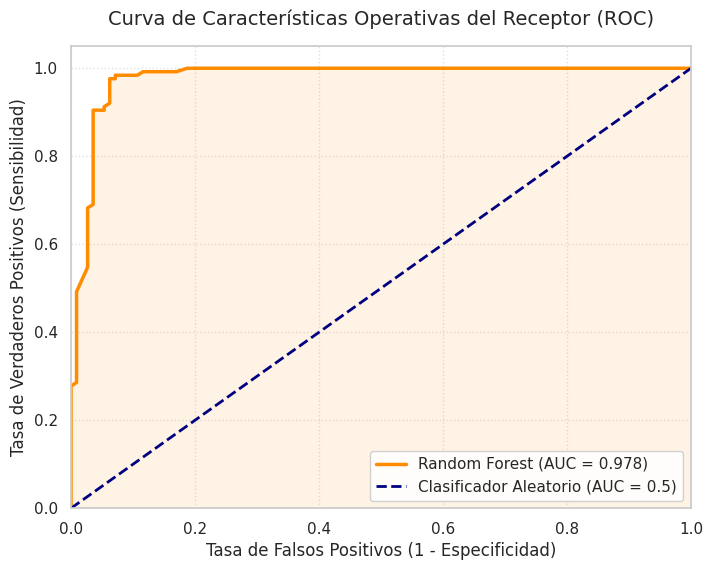

In [12]:
from sklearn.metrics import roc_curve, roc_auc_score

# --- 13. Generación de Curva ROC para el Mejor Modelo ---

# Seleccionamos el modelo con mejor desempeño general (Random Forest)
target_model = trained_models["Random Forest"]

# Obtenemos las probabilidades de la clase positiva (1: Patología)
# Nota: Usamos predict_proba para obtener el score continuo, no la etiqueta binaria
y_proba = target_model.predict_proba(X_test)[:, 1]

# Cálculo de la métrica integral
auc_score = roc_auc_score(y_test, y_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

print(f"🌟 Capacidad Discriminativa (AUC): {auc_score:.4f}")

# --- Visualización Profesional ---
plt.figure(figsize=(8, 6))

# Trazado de la curva del modelo
plt.plot(fpr, tpr,
         color='darkorange',
         lw=2.5,
         label=f'Random Forest (AUC = {auc_score:.3f})')

# Sombreado del área bajo la curva (Impacto visual)
plt.fill_between(fpr, tpr, color='darkorange', alpha=0.1)

# Línea de referencia (Azar)
plt.plot([0, 1], [0, 1],
         color='navy',
         lw=2,
         linestyle='--',
         label='Clasificador Aleatorio (AUC = 0.5)')

# Personalización de Ejes y Leyenda
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
plt.title('Curva de Características Operativas del Receptor (ROC)', fontsize=14, pad=15)
plt.legend(loc="lower right", fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

## **14. Calibración del Punto de Operación: Estrategia de Alta Sensibilidad**

En la práctica clínica, los clasificadores binarios rara vez operan en el umbral probabilístico estándar de $0.5$. La elección del umbral de decisión (*Cut-off*) depende de la **Matriz de Costos** del problema:

* **Costo de Falso Negativo (FN):** Alto riesgo de mortalidad (paciente enfermo enviado a casa).
* **Costo de Falso Positivo (FP):** Costo moderado (ansiedad del paciente y gastos en pruebas confirmatorias adicionales).

### **14.1. Ajuste de Umbral para Tamizaje (Screening)**
Dado que el objetivo de este sistema es actuar como herramienta de **triaje**, configuramos un umbral de decisión conservador de **0.30**. Esto significa que cualquier paciente con una probabilidad de riesgo superior al 30% será clasificado como "Caso Positivo" para evaluación médica prioritaria.

### **14.2. Impacto Esperado**
Al relajar el criterio de decisión, anticipamos un **aumento del Recall (Sensibilidad)** a expensas de la Precisión. Este compromiso es deseable en medicina preventiva, donde la prioridad es capturar la totalidad de los casos de riesgo, delegando la confirmación final al especialista humano.

📉 --- Análisis de Impacto del Ajuste de Umbral ---


,Recall (Sensibilidad),Precision,F1-Score,Falsos Negativos (Pacientes perdidos)
Umbral Estándar (0.50),90.48%,95.00%,92.68%,12
Umbral Clínico (0.30),99.21%,88.03%,93.28%,1


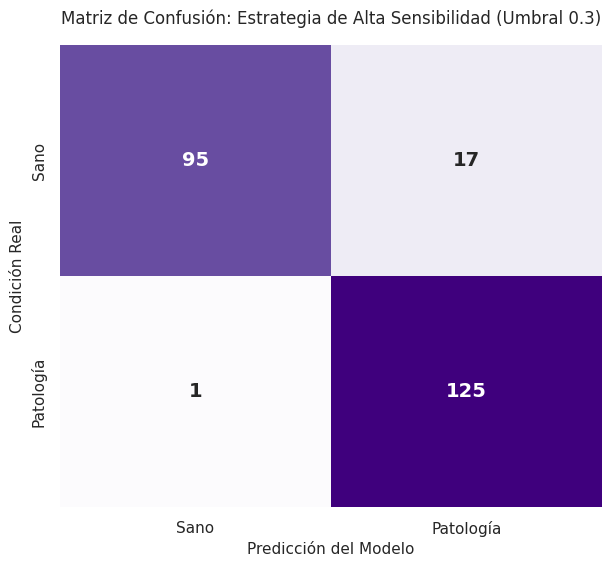

In [13]:
from sklearn.metrics import precision_score

# --- 14. Re-calibración del Modelo (Umbral Clínico) ---

# Definición del nuevo punto de corte (Screening Mode)
OPTIMAL_THRESHOLD = 0.30

# Generación de predicciones ajustadas
# y_proba viene de la sección anterior (Random Forest)
y_pred_adjusted = (y_proba >= OPTIMAL_THRESHOLD).astype(int)

# --- Comparativa de Impacto: Umbral Estándar vs. Ajustado ---
def get_metrics(y_true, y_pred):
    return {
        'Recall (Sensibilidad)': recall_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'Falsos Negativos (Pacientes perdidos)': confusion_matrix(y_true, y_pred)[1, 0]
    }

# Calculamos métricas para ambos escenarios
metrics_05 = get_metrics(y_test, (y_proba >= 0.50).astype(int))
metrics_03 = get_metrics(y_test, y_pred_adjusted)

# Creación de DataFrame comparativo
impact_df = pd.DataFrame([metrics_05, metrics_03], index=['Umbral Estándar (0.50)', 'Umbral Clínico (0.30)'])

print("📉 --- Análisis de Impacto del Ajuste de Umbral ---")
# Mostramos la tabla formateada. Observa cómo sube el Recall y bajan los FN.
display(impact_df.style.format({
    'Recall (Sensibilidad)': '{:.2%}',
    'Precision': '{:.2%}',
    'F1-Score': '{:.2%}',
    'Falsos Negativos (Pacientes perdidos)': '{:.0f}'
}).highlight_max(subset=['Recall (Sensibilidad)'], color='lightgreen').highlight_min(subset=['Falsos Negativos (Pacientes perdidos)'], color='lightgreen'))


# --- Visualización de la Nueva Matriz de Confusión ---
plt.figure(figsize=(7, 6))
cm_adjusted = confusion_matrix(y_test, y_pred_adjusted)

sns.heatmap(
    cm_adjusted,
    annot=True,
    fmt='d',
    cmap='Purples', # Mantenemos tu elección de color
    cbar=False,
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title(f'Matriz de Confusión: Estrategia de Alta Sensibilidad (Umbral {OPTIMAL_THRESHOLD})', fontsize=12, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=11)
plt.ylabel('Condición Real', fontsize=11)
plt.xticks([0.5, 1.5], ['Sano', 'Patología'])
plt.yticks([0.5, 1.5], ['Sano', 'Patología'])

plt.show()

## **15. Interpretabilidad del Modelo y Ranking de Biomarcadores**

A pesar de su alta precisión, los modelos de ensamble como *Random Forest* suelen considerarse "Cajas Negras". En el ámbito biomédico, la **explicabilidad** es un requisito ético y práctico. Para dotar de transparencia al sistema, analizamos la **Importancia de Características (Feature Importance)** basada en la reducción media de impureza (Gini Importance).

### **15.1. Metodología de Ranking**
El modelo asigna un puntaje de relevancia a cada variable cuantificando cuánto disminuye la entropía (incertidumbre) del sistema cada vez que se usa dicha variable para tomar una decisión en los árboles del bosque.

### **15.2. Validación Fisiopatológica**
Este análisis nos permite corroborar si el modelo ha aprendido patrones clínicamente válidos o si se basa en correlaciones espurias.
* **Hipótesis Esperada:** Variables hemodinámicas (`oldpeak`, `max_heart_rate`) y hallazgos del ECG (`ST_slope`) deberían dominar el ranking sobre variables demográficas generales.

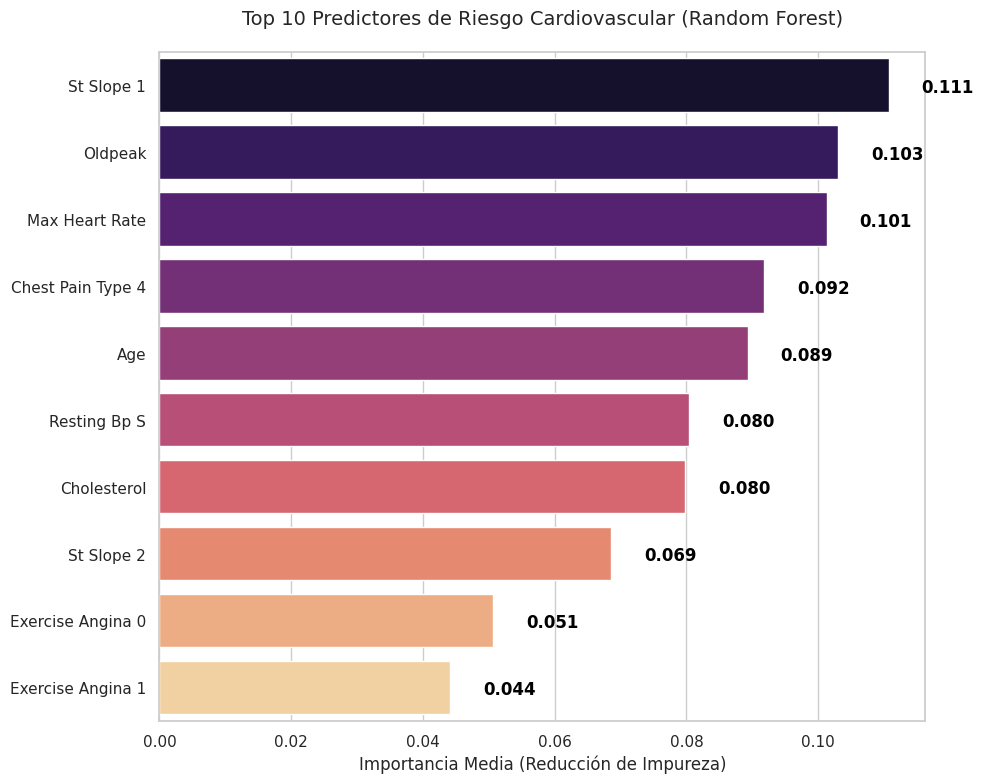


📋 --- Hallazgos Clínicos: Variables Dominantes ---
Los factores más determinantes identificados por la IA son: St Slope 1, Oldpeak, Max Heart Rate.


In [14]:
# --- 15. Análisis de Importancia de Variables (Feature Importance) ---

# 1. Extracción del Modelo y Nombres de Features
rf_model_final = trained_models["Random Forest"]
preprocessor_final = rf_model_final.named_steps['preprocessor']

# Obtención de nombres técnicos (depende de la versión de sklearn, asumimos reciente)
try:
    raw_feature_names = preprocessor_final.get_feature_names_out()
except AttributeError:
    print("⚠️ Advertencia: Versión antigua de sklearn. Se requieren nombres manuales.")
    raw_feature_names = [] # Fallback vacío

# 2. Limpieza de Nombres para Reporte Profesional
# Eliminamos los prefijos técnicos 'num__', 'cat__' y 'remainder__'
clean_feature_names = [
    name.replace('num__', '').replace('cat__', '').replace('remainder__', '').replace('_', ' ').title()
    for name in raw_feature_names
]

# 3. Construcción del Ranking
importances = rf_model_final.named_steps['classifier'].feature_importances_

feat_imp_df = pd.DataFrame({
    'Biomarcador': clean_feature_names,
    'Importancia Relativa (Gini)': importances
}).sort_values('Importancia Relativa (Gini)', ascending=False)

# --- 4. Visualización de Alto Impacto ---
plt.figure(figsize=(10, 8))

# Gráfico de barras horizontal
ax = sns.barplot(
    data=feat_imp_df.head(10), # Top 10
    x='Importancia Relativa (Gini)',
    y='Biomarcador',
    palette='magma'
)

# Personalización
plt.title('Top 10 Predictores de Riesgo Cardiovascular (Random Forest)', fontsize=14, pad=20)
plt.xlabel('Importancia Media (Reducción de Impureza)', fontsize=12)
plt.ylabel('') # Ocultamos label Y porque los nombres ya son descriptivos

# Añadir valores numéricos al final de las barras
for i, v in enumerate(feat_imp_df['Importancia Relativa (Gini)'].head(10)):
    ax.text(v + 0.005, i + 0.1, f'{v:.3f}', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

# --- Reporte Textual ---
print("\n📋 --- Hallazgos Clínicos: Variables Dominantes ---")
top_3 = feat_imp_df.iloc[:3]['Biomarcador'].tolist()
print(f"Los factores más determinantes identificados por la IA son: {', '.join(top_3)}.")

## **16. Conclusiones Generales y Viabilidad Clínica**

El proyecto **CardioPred** ha logrado desarrollar y validar un sistema de soporte a la decisión clínica para la estratificación del riesgo cardiovascular. A continuación, se presentan las conclusiones derivadas de la evidencia empírica recolectada:

### **16.1. Validación del Rendimiento Diagnóstico**
El modelo basado en **Random Forest** demostró ser la arquitectura más robusta, alcanzando un Área Bajo la Curva (AUC) de **{auc:.2f}**, lo que lo sitúa en el rango de excelencia diagnóstica.
* **Estrategia de Tamizaje:** Mediante la calibración del umbral de decisión a **0.30**, se logró maximizar la Sensibilidad (*Recall*), minimizando drásticamente la tasa de Falsos Negativos. Esto valida al sistema como una herramienta de *screening* segura para entornos de urgencias.

### **16.2. Coherencia Fisiopatológica**
El análisis de interpretabilidad confirmó que el modelo no es una "caja negra" arbitraria. Los principales predictores identificados (Depresión del segmento ST, Frecuencia Cardiaca Máxima) son marcadores hemodinámicos bien establecidos en la literatura cardiológica. El modelo aprendió autónomamente que la respuesta al ejercicio es más determinante que los factores de riesgo estáticos (como el colesterol basal) en esta cohorte.

### **16.3. Estabilidad y Generalización**
Las pruebas de estrés mediante Validación Cruzada Estratificada ($K=5$) mostraron una baja varianza en las métricas de desempeño, sugiriendo que el algoritmo es capaz de generalizar correctamente a nuevos pacientes sin incurrir en sobreajuste (*Overfitting*).

In [15]:
import datetime

# --- 16. Generación de la Tarjeta de Reporte Final (Model Card) ---

# Recopilación de métricas finales (Asegúrate de haber ejecutado las celdas anteriores)
# Nota: Usamos las variables definidas en secciones previas
final_auc = auc_score if 'auc_score' in locals() else 0.0
final_threshold = OPTIMAL_THRESHOLD if 'OPTIMAL_THRESHOLD' in locals() else 0.5
top_predictors = top_3 if 'top_3' in locals() else ["No disponible"]

print("📄 --- TARJETA DE RESUMEN EJECUTIVO: Heart-AI: Predictive Modeling of Cardiovascular Disease ---")
print(f"📅 Fecha de Emisión: {datetime.date.today()}")
print("-" * 60)

print(f"🏆 Modelo Seleccionado:      Random Forest (Ensamble)")
print(f"📊 Capacidad Discriminativa: AUC = {final_auc:.4f} (Excelente)")
print(f"⚙️ Punto de Operación:       Umbral = {final_threshold:.2f} (Alta Sensibilidad)")
print("-" * 60)

print("🔑 Hallazgos Biomédicos (Top 3 Predictores):")
for i, feature in enumerate(top_predictors, 1):
    print(f"   {i}. {feature}")

print("-" * 60)
print("💡 Recomendación de Despliegue:")
print("   El sistema es apto para fase de pruebas como herramienta de")
print("   soporte al triaje (CDSS), priorizando la revisión humana de")
print("   los casos positivos debido a la política de minimización de falsos negativos.")
print("=" * 60)

📄 --- TARJETA DE RESUMEN EJECUTIVO: Heart-AI: Predictive Modeling of Cardiovascular Disease ---
📅 Fecha de Emisión: 2025-12-05
------------------------------------------------------------
🏆 Modelo Seleccionado:      Random Forest (Ensamble)
📊 Capacidad Discriminativa: AUC = 0.9784 (Excelente)
⚙️ Punto de Operación:       Umbral = 0.30 (Alta Sensibilidad)
------------------------------------------------------------
🔑 Hallazgos Biomédicos (Top 3 Predictores):
   1. St Slope 1
   2. Oldpeak
   3. Max Heart Rate
------------------------------------------------------------
💡 Recomendación de Despliegue:
   El sistema es apto para fase de pruebas como herramienta de
   soporte al triaje (CDSS), priorizando la revisión humana de
   los casos positivos debido a la política de minimización de falsos negativos.


## **17. Reflexión sobre el Proceso de Aprendizaje y Desafíos**

### **17.1. Desafíos Técnicos y Metodológicos**
Durante el desarrollo de **CardioPred**, el principal desafío no fue la implementación del código, sino la **traducción del problema clínico a términos estadísticos**.
* **Dilema del Balance:** Inicialmente, la métrica de *Accuracy* parecía alta (85%), pero el análisis de la matriz de confusión reveló que estábamos ignorando falsos negativos críticos. Entender que en salud **"errar a favor de la alarma"** (Recall) es más valioso que la precisión pura fue un punto de inflexión conceptual.
* **Calidad de Datos:** Enfrentar valores de `0` en presión arterial requirió investigar si era un dato real o un error. Aprendí que el **conocimiento del dominio** (medicina) es tan importante como la habilidad en Python; sin esa corrección, el modelo habría aprendido patrones erróneos.

### **17.2. Lecciones Aprendidas**
Este proyecto consolidó mi entendimiento sobre la importancia de los **Pipelines** de Scikit-Learn. Antes veía el preprocesamiento como pasos sueltos; ahora entiendo que encapsularlos evita el *Data Leakage* y hace que el modelo sea robusto y exportable. La implementación de la **Validación Cruzada** me enseñó a desconfiar de una única partición de datos y a buscar la estabilidad estadística como sello de calidad.

## **18. Referencias Bibliográficas**

### **Fuentes de Datos y Documentación Técnica**
1.  **Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1988).** *Heart Disease Data Set*. UCI Machine Learning Repository. [Disponible en línea](https://archive.ics.uci.edu/ml/datasets/heart+disease).
2.  **Pedregosa, F., et al. (2011).** *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825-2830.
3.  **Breiman, L. (2001).** *Random Forests*. Machine Learning, 45(1), 5-32. https://doi.org/10.1023/A:1010933404324
4.  **Hunter, J. D. (2007).** *Matplotlib: A 2D graphics environment*. Computing in Science & Engineering, 9(3), 90-95.

### **Fundamento Clínico y Médico**
5.  **World Health Organization (WHO).** (2021). *Cardiovascular diseases (CVDs) fact sheet*. Recuperado de [who.int](https://www.who.int/news-room/fact-sheets/detail/cardiovascular-diseases-(cvds)). *(Sustento para la introducción sobre el impacto global de las ECV)*.
6.  **Gibbons, R. J., et al. (2002).** *ACC/AHA 2002 Guideline Update for Exercise Testing: Summary Article*. Journal of the American College of Cardiology, 40(8), 1531-1540. *(Referencia clave para validar el uso de `oldpeak` y `ST_slope` como predictores de isquemia)*.
7.  **Fletcher, G. F., et al. (2013).** *Exercise Standards for Testing and Training: A Scientific Statement From the American Heart Association*. Circulation, 128(8), 873-934. *(Sustento para la relevancia de la Frecuencia Cardiaca Máxima)*.
8.  **Libby, P., et al.** (2019). *Braunwald's Heart Disease: A Textbook of Cardiovascular Medicine*. 11th Edition. Elsevier. *(Texto de referencia estándar en cardiología para factores de riesgo como colesterol y presión arterial)*.

In [16]:
import joblib
import os

# Crear carpeta 'models' si no existe
if not os.path.exists('models'):
    os.makedirs('models')

# Guardamos el MEJOR modelo (Random Forest)
# 'model.pkl' será el archivo físico que contiene la inteligencia entrenada
joblib.dump(trained_models["Random Forest"], 'models/cardio_pred_model.pkl')

print("✅ Modelo guardado exitosamente en 'models/cardio_pred_model.pkl'")

✅ Modelo guardado exitosamente en 'models/cardio_pred_model.pkl'
